Decision Trees for Classification

Student name: Boomiga Mathanavel / Student id: 24136630

Github : https://github.com/boomiga18/decision-tree-titanic-classification.git

In [10]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [11]:
# Load data from seaborn
df = sns.load_dataset('titanic')
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
# Keep only useful columns
df = df[['survived', 'pclass', 'sex', 'age', 'fare']].dropna()

# Convert sex to numbers (male=0, female=1)
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

print(df.shape)
df.head()

(714, 5)


,survived,pclass,sex,age,fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [13]:
X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (571, 4)
Test size: (143, 4)


In [14]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [15]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7412587412587412

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        87
           1       0.69      0.61      0.65        56

    accuracy                           0.74       143
   macro avg       0.73      0.72      0.72       143
weighted avg       0.74      0.74      0.74       143



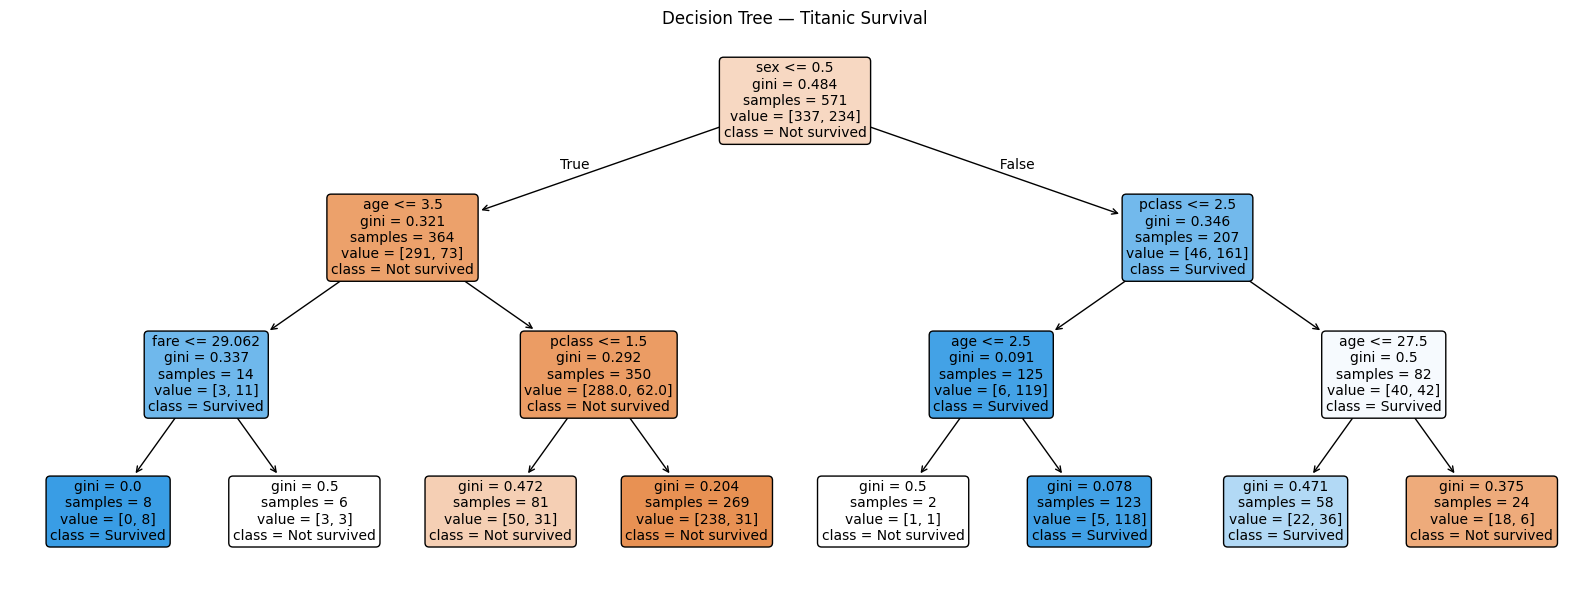

In [16]:
plt.figure(figsize=(16, 6))
plot_tree(model,
          feature_names=['pclass', 'sex', 'age', 'fare'],
          class_names=['Not survived', 'Survived'],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree — Titanic Survival")
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150)
plt.show()

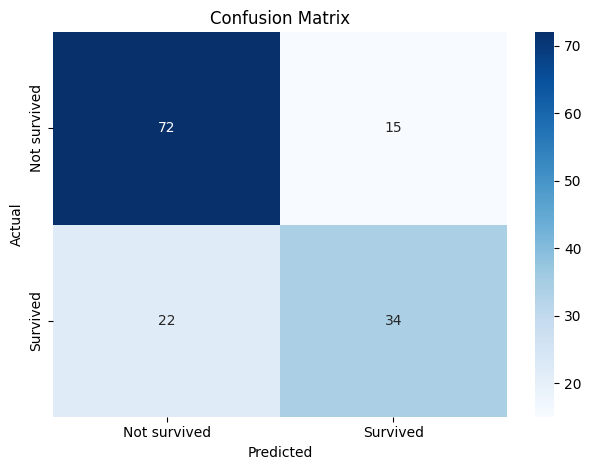

In [17]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not survived', 'Survived'],
            yticklabels=['Not survived', 'Survived'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()